In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
from tensorflow.keras.metrics import (
     Precision, Recall, BinaryAccuracy, AUC, FalsePositives, FalseNegatives, TruePositives, TrueNegatives
     )
from keras.regularizers import l2
from tensorflow.keras.callbacks import Callback, CSVLogger, EarlyStopping, LearningRateScheduler, ReduceLROnPlateau, TensorBoard
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from tensorboard.plugins.hparams import api as hp
#import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import datetime
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint


In [2]:
wnadb_api_key = "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"
wandb.login(key=wnadb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Mohamed.Gomaa\_netrc
wandb: Currently logged in as: mohamed-gomaa6 (mohamed-gomaa6-student-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
run = wandb.init(project="malaria_classification", name="malaria_dev-3")

wandb: Currently logged in as: mohamed-gomaa6 (mohamed-gomaa6-student-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
DATA_DIR = './dataset'
dataset, dataset_info = tfds.load('malaria', with_info=True, data_dir=DATA_DIR, shuffle_files=True)

In [104]:
dataset_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='dataset\\malaria\\1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasite detection in t

In [6]:
print(len(dataset['train']))
# dataset['train'] = dataset['train'].take(10000)
# print(len(dataset['train']))

27558


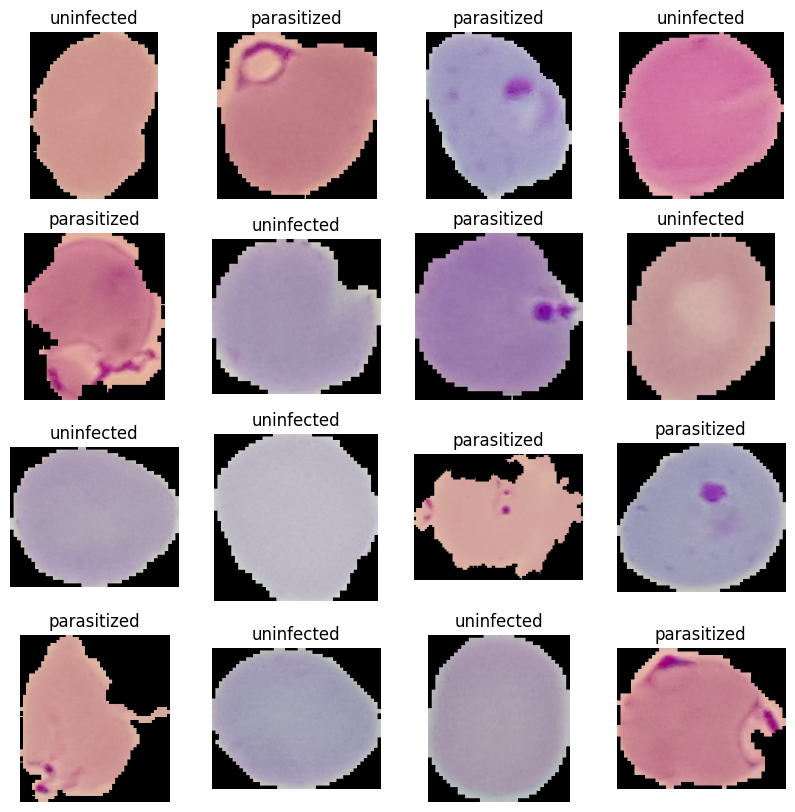

In [124]:
def int2str(label):
  ma = ['parasitized', 'uninfected'] 
  return ma[label]
  
plt.figure(figsize=(10, 10))
for i, row_data in enumerate(dataset['train'].take(16)):
    plt.subplot(4, 4, i+1)
    plt.imshow(row_data['image'])
    plt.title(int2str(row_data['label'].numpy()))
    plt.axis('off')

In [4]:
def split_data(dataset, train_ratio=0.8, test_ratio=0.1, val_ratio=0.1):
    total_size = len(dataset) 
    train_datset = dataset.take(int(total_size*train_ratio))
    val_datset = dataset.skip(int(total_size*train_ratio)).take(int(total_size*val_ratio))
    test_datset = dataset.skip(int(total_size*(train_ratio+val_ratio)))
    return train_datset, val_datset, test_datset


In [5]:
train_data, val_data, test_data = split_data(dataset['train'])

In [8]:
len(train_data), len(val_data), len(test_data)

(22046, 2755, 2756)

In [12]:
for ex in train_data.take(5):
    print(ex['image'].shape)

(151, 115, 3)
(121, 115, 3)
(157, 136, 3)
(103, 103, 3)
(106, 121, 3)


### Preprocessing && Augmentation

In [6]:
SIZE= 224
batch_size = 32
def rescale_resize(inp):
     image = inp['image']
     image = tf.image.resize(image, (224, 224))
     image = tf.cast(image, tf.float32) / 255.0
     return image, inp['label']

def unpack(inp):
    return inp['image'], inp['label']
     

tf.Tensor(67362.555, shape=(), dtype=float32)
tf.Tensor(77666.32, shape=(), dtype=float32)
tf.Tensor(67712.555, shape=(), dtype=float32)


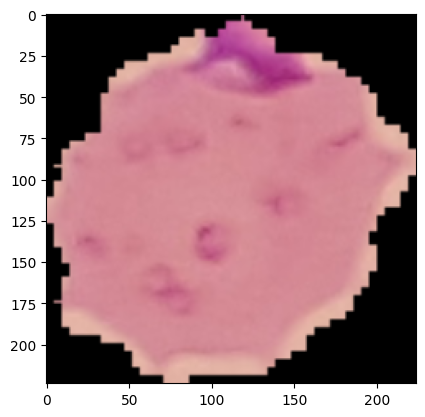

In [10]:
for raw_data in dataset['train'].take(3):
    image, label = rescale_resize(raw_data)
    plt.imshow(image)
    print(tf.reduce_sum(image))

In [438]:
inp = next(iter(train_data))
def visualize(original, augmented):
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.subplot(1, 2, 2)
    plt.imshow(augmented)

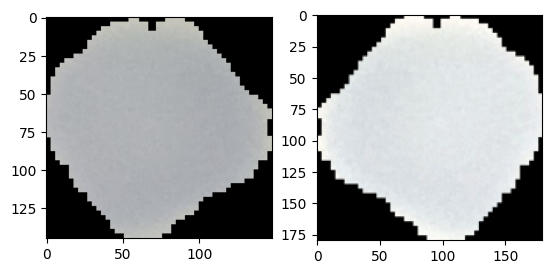

In [495]:
augmented, _ = augment_albument(inp)
visualize(inp['image'], augmented)

In [10]:
# tf.image augmentation applied on data pipeline
def augment(inp):
    image = tf.image.adjust_brightness(inp['image'], delta=0.2)
    image = tf.image.adjust_saturation(image, 2)
    image = tf.image.adjust_gamma(image, gamma=1.4, gain=1.5)
    image = tf.image.flip_left_right(image)
    return {'image': image, 'label':inp['label']}

In [ ]:
# Albumentation Augmentaion
transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.SquareSymmetry(p=0.5),  # All 8 rotations/flips - proper for medical data
    A.Rotate(limit=-45, p=0.6, border_mode=4),  # Rotate by a small angle - proper for medical data
    #A.ChannelDropout(channel_drop_range=(1, 2), fill=128, p=0.6),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    ], p=0.6),
    # A.OneOf([
    #     A.GaussianBlur(blur_limit=(1, 3), p=1.0),
    #     A.GaussNoise(var_limit=(10, 50), p=1.0),
    # ], p=0.3),
    A.Resize(224, 224),  
])

def augment_albument_func(image):
    image_np = {'image': image}
    transformed = transforms(**image_np)
    image = transformed['image']
    image = tf.cast(image/255, dtype=tf.float32)
    return image

def augment_albument(inp):
    aug_image = tf.numpy_function(func=augment_albument_func, inp=[inp['image']], Tout=tf.float32)
    aug_image.set_shape((224, 224, 3))
    return aug_image, inp['label']

In [7]:
train_data, val_data, test_data = train_data.take(700), val_data.take(100), test_data.take(100)
len(train_data), len(val_data), len(test_data)

(700, 100, 100)

In [8]:
train_data = train_data.map(rescale_resize).shuffle(buffer_size=8, reshuffle_each_iteration=True).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_data = val_data.map(rescale_resize).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_data = test_data.map(rescale_resize).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [9]:
len(train_data), len(val_data), len(test_data)

(22, 4, 4)

### CNN Model

In [244]:
# keras.layers used inside the model applied on training data ---> random means images changed each epoch
data_augmentation_layer = tf.keras.Sequential([
    #tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    #tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
], name="data_augmentation")

In [10]:
wandb.config = {
    "batch_size": 32,
    "image_size": 224,
    "learning_rate": 1e-3,
    "dropout_rate": 0.4,
    "num_filters": 16,
    "pool_size": 2,
    "kernel_size": 3,
    "cnn_kernel_regularizer": 0.01,
    "dense_kernel_regularizer": 0.02,
    "unit_1": 128,
    "unit_2": 64,
}

config = wandb.config


In [ ]:
model = keras.Sequential(
    [
        layers.InputLayer(shape=(config['image_size'], config['image_size'], 3)),


        layers.Conv2D(filters=config['num_filters'], kernel_size=config['kernel_size'], strides=1, padding='valid', kernel_regularizer=l2(config['cnn_kernel_regularizer'])),
        layers.MaxPool2D(pool_size=config['pool_size'], strides=2),
        layers.BatchNormalization(), 
        layers.Activation('relu'),

        layers.Conv2D(filters=2*config['num_filters'], kernel_size=config['kernel_size'], strides=1, padding='valid', kernel_regularizer=l2(config['cnn_kernel_regularizer'])),
        layers.MaxPool2D(pool_size=config['pool_size'], strides=2),
        layers.BatchNormalization(), 
        layers.Activation('relu'),
    
        layers.Dropout(config['dropout_rate']),      
  
        layers.Conv2D(filters=4*config['num_filters'], kernel_size=config['kernel_size'], strides=1, padding='valid', kernel_regularizer=l2(config['dense_kernel_regularizer'])),
        layers.MaxPool2D(pool_size=config['pool_size'], strides=2),
        layers.BatchNormalization(),
        layers.Activation('relu'), 
        layers.Dropout(config['dropout_rate']),

        layers.Flatten(),
        layers.Dense(config['unit_1'], kernel_regularizer=l2(config['dense_kernel_regularizer'])),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(config['dropout_rate']),

        layers.Dense(config['unit_2'], kernel_regularizer=l2(config['dense_kernel_regularizer'])),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(config['dropout_rate']),

        layers.Dense(1, activation='sigmoid'),
    ]
)
model.summary()

c:\Users\Mohamed.Gomaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,571,041 (21.25 MB)

 Trainable params: 5,570,433 (21.25 MB)

 Non-trainable params: 608 (2.38 KB)

In [48]:
#Hyperparameters Tunning
hp_learning_rate = hp.HParam('learning_rate', hp.Discrete([0.001, 0.0001]))
hp_dropout_rate = hp.HParam('dropout_rate', hp.Discrete([0.1, 0.2]))
hp_units_one = hp.HParam('units_one', hp.Discrete([32, 64]))
hp_units_two = hp.HParam('units_two', hp.Discrete([32]))

def get_best_hparams():
    best_params = {}
    best_accuracy = 0.0
    run_num = 0
    
    for lr in hp_learning_rate.domain.values:
        for dr in hp_dropout_rate.domain.values:
            for u1 in hp_units_one.domain.values:
                for u2 in hp_units_two.domain.values:
                    # Build and compile the model with current hyperparameters
                    model = keras.Sequential(
                        [
                            layers.InputLayer(input_shape=(SIZE, SIZE, 3)),
                            layers.Conv2D(filters=16, kernel_size=3, strides=1, padding='valid', activation='relu'),
                            layers.MaxPool2D(pool_size=2, strides=2),
                            layers.BatchNormalization(), 
                            layers.Conv2D(filters=32, kernel_size=3, strides=1, padding='valid', activation='relu'),
                            layers.MaxPool2D(pool_size=2, strides=2),
                            layers.BatchNormalization(),
                            layers.Dropout(dr),      
                            layers.Conv2D(filters=64, kernel_size=3, strides=1, padding='valid', activation='relu'),
                            layers.MaxPool2D(pool_size=2, strides=2),
                            layers.BatchNormalization(), 
                            layers.Dropout(dr),
                            layers.Flatten(),
                            layers.Dense(u1, activation='relu'),
                            layers.BatchNormalization(),
                            layers.Dense(u2, activation='relu'),
                            layers.BatchNormalization(),
                            layers.Dense(1, activation='sigmoid'),
                        ]
                    )
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])
                    
                    # Train the model
                    history = model.fit(val_data, epochs=1)
                    
                    # Evaluate the model on validation data
                    _, accuracy = model.evaluate(val_data)

                    params = {
                        'learning_rate': lr,
                        'dropout_rate': dr,
                        'units_one': u1,
                        'units_two': u2
                        }
                    file_write = tf.summary.create_file_writer('logs/' + str(run_num))
                    with file_write.as_default():
                        hp.hparams(params)  # Log the hyperparameters
                        tf.summary.scalar('accuracy', accuracy, step=run_num)  # Log the accuracy
                    run_num += 1
                    
                    del model

                    print(f"LR: {lr}, Dropout: {dr}, Units1: {u1}, Units2: {u2}, Val Loss: {accuracy}")
                    
                    # Update best parameters if current accuracy is better
                    if accuracy > best_accuracy:
                        best_accuracy = accuracy
                        best_params = {
                            'learning_rate': lr,
                            'dropout_rate': dr,
                            'units_one': u1,
                            'units_two': u2
                        }
    
    return best_params  


In [49]:
best_params = get_best_hparams()
print("Best Hyperparameters:", best_params)

40/40 [==============================] - 8s 135ms/step - loss: 0.6951 - accuracy: 0.5063
LR: 0.0001, Dropout: 0.1, Units1: 32, Units2: 32, Val Loss: 0.5062500238418579
40/40 [==============================] - 8s 137ms/step - loss: 0.7444 - accuracy: 0.4906
LR: 0.0001, Dropout: 0.1, Units1: 64, Units2: 32, Val Loss: 0.4906249940395355
40/40 [==============================] - 8s 136ms/step - loss: 0.6872 - accuracy: 0.5781
LR: 0.0001, Dropout: 0.2, Units1: 32, Units2: 32, Val Loss: 0.578125
40/40 [==============================] - 9s 157ms/step - loss: 0.7652 - accuracy: 0.5133
LR: 0.0001, Dropout: 0.2, Units1: 64, Units2: 32, Val Loss: 0.5132812261581421
40/40 [==============================] - 8s 142ms/step - loss: 0.7010 - accuracy: 0.4875
LR: 0.001, Dropout: 0.1, Units1: 32, Units2: 32, Val Loss: 0.48750001192092896
40/40 [==============================] - 8s 145ms/step - loss: 0.7048 - accuracy: 0.4820
LR: 0.001, Dropout: 0.1, Units1: 64, Units2: 32, Val Loss: 0.4820312559604645
40/

#### Hayperparameter Tunning by Wandb

In [11]:
config

{'batch_size': 32,
 'image_size': 224,
 'learning_rate': 0.001,
 'dropout_rate': 0.4,
 'num_filters': 16,
 'pool_size': 2,
 'kernel_size': 3,
 'cnn_kernel_regularizer': 0.01,
 'dense_kernel_regularizer': 0.02,
 'unit_1': 128,
 'unit_2': 64}

In [12]:
sweep_config = {
    "name": "sweepdhpt",
    "method": "random",
    "metric": {"goal": "minimize", "name": "validation_loss"},
    "parameters": {
        "image_size":{
            "value": 224
        },
        "batch_size":{
            "value": 32
        },
        "learning_rate": {
            "distribution": "uniform",
            "min": 1e-4,
            "max": 0.01
            },
        "dropout_rate": {
            "distribution": "uniform",
            "min": 0.1,
            "max": 0.5,
        },
        "num_filters": {"values": [16, 32, 64]},
        "pool_size": {"values": [2, 3]},
        "kernel_size": {"values": [3, 5]},
        "cnn_kernel_regularizer": {
            "distribution": "uniform",
            "min": 0.001,
            "max": 0.1,
        },
        "dense_kernel_regularizer": {
            "distribution": "uniform",
            "min": 0.001,
            "max": 0.1,
        },
        "unit_1": {"values": [64, 128, 256]},
        "unit_2": {"values": [32, 64, 128]},
    },
}

In [13]:
def build_model(config):
    model = keras.Sequential(
        [
            layers.InputLayer(input_shape=(config['image_size'], config['image_size'], 3)),
            layers.Conv2D(filters=config['num_filters'], kernel_size=config['kernel_size'], strides=1, padding='valid', kernel_regularizer=l2(config['cnn_kernel_regularizer'])),
            layers.MaxPool2D(pool_size=config['pool_size'], strides=2),
            layers.BatchNormalization(), 
            layers.Activation('relu'),
            layers.Conv2D(filters=2*config['num_filters'], kernel_size=config['kernel_size'], strides=1, padding='valid', kernel_regularizer=l2(config['cnn_kernel_regularizer'])),
            layers.MaxPool2D(pool_size=config['pool_size'], strides=2),
            layers.BatchNormalization(), 
            layers.Activation('relu'),
            layers.Dropout(config['dropout_rate']),      
            layers.Conv2D(filters=4*config['num_filters'], kernel_size=config['kernel_size'], strides=1, padding='valid', kernel_regularizer=l2(config['dense_kernel_regularizer'])),
            layers.MaxPool2D(pool_size=config['pool_size'], strides=2),
            layers.BatchNormalization(),
            layers.Activation('relu'), 
            layers.Dropout(config['dropout_rate']),
            layers.Flatten(),
            layers.Dense(config['unit_1'], kernel_regularizer=l2(config['dense_kernel_regularizer'])),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(config['dropout_rate']),
            layers.Dense(config['unit_2'], kernel_regularizer=l2(config['dense_kernel_regularizer'])),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(config['dropout_rate']),
            layers.Dense(1, activation='sigmoid'),
        ]
    )
    return model

In [15]:
def train():
    with  wandb.init():
         config = wandb.config
         model = build_model(config)
         model.compile(
              optimizer=keras.optimizers.Adam(learning_rate=config['learning_rate']),
              loss=keras.losses.BinaryCrossentropy(),
              metrics=[BinaryAccuracy()])
         model.fit(val_data, validation_data=val_data, epochs=4, callbacks=[WandbMetricsLogger()])



sweep_id = wandb.sweep(sweep_config, project="Malaria-Classification-HpTn")
wandb.agent(sweep_id, function=train, count=5)

Create sweep with ID: jfom6y9y
Sweep URL: https://wandb.ai/mohamed-gomaa6-student-/Malaria-Classification-HpTn/sweeps/jfom6y9y


wandb: Agent Starting Run: kf2c4624 with config:
wandb: 	batch_size: 32
wandb: 	cnn_kernel_regularizer: 0.03359919438241782
wandb: 	dense_kernel_regularizer: 0.09693095912543966
wandb: 	dropout_rate: 0.4745722671294622
wandb: 	image_size: 224
wandb: 	kernel_size: 5
wandb: 	learning_rate: 0.005233596241314908
wandb: 	num_filters: 32
wandb: 	pool_size: 3
wandb: 	unit_1: 256
wandb: 	unit_2: 32
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Mohamed.Gomaa\_netrc.


c:\Users\Mohamed.Gomaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/4
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - binary_accuracy: 0.5500 - loss: 73.0314 - val_binary_accuracy: 0.5500 - val_loss: 94.8723
Epoch 2/4
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - binary_accuracy: 0.5800 - loss: 81.3318 - val_binary_accuracy: 0.4500 - val_loss: 61.4045
Epoch 3/4
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - binary_accuracy: 0.4600 - loss: 54.8498 - val_binary_accuracy: 0.5200 - val_loss: 40.6352
Epoch 4/4
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - binary_accuracy: 0.4400 - loss: 37.2635 - val_binary_accuracy: 0.5200 - val_loss: 30.5560


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

Epoch 1/4


c:\Users\Mohamed.Gomaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - binary_accuracy: 0.5500 - loss: 65.6341 - val_binary_accuracy: 0.6300 - val_loss: 110.4906
Epoch 2/4
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - binary_accuracy: 0.4800 - loss: 91.7616 - val_binary_accuracy: 0.5500 - val_loss: 76.9153
Epoch 3/4
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - binary_accuracy: 0.6600 - loss: 58.3144 - val_binary_accuracy: 0.4500 - val_loss: 48.3228
Epoch 4/4
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - binary_accuracy: 0.6600 - loss: 34.6469 - val_binary_accuracy: 0.6000 - val_loss: 26.2393


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch/binary_accuracy,▄▁██
epoch/epoch,▁▃▆█
epoch/learning_rate,▁▁▁▁
epoch/loss,▅█▄▁
epoch/val_binary_accuracy,█▅▁▇
epoch/val_loss,█▅▃▁
epoch/binary_accuracy,0.66
epoch/epoch,3
epoch/learning_rate,0.00907
epoch/loss,34.64687
epoch/val_binary_accuracy,0.6


#### Training

In [202]:
metrics = [
    BinaryAccuracy(name='accuracy'), TruePositives(name='tp'), FalsePositives(name='fp'), TrueNegatives(name='tn'), 
    FalseNegatives(name='fn'), Precision(name='precision'), Recall(name='recall'), AUC(name='auc')
]

In [51]:
# for savong a csv file with this logs
csv_callback = CSVLogger('logs.csv', separator=',', append=True)

In [52]:
# for interupt the training loop when overfitting or underfitting accur
es_callback = EarlyStopping(
    monitor='val_loss', min_delta=0.0005, patience=3, verbose=1,
    mode='auto', baseline=None, restore_best_weights=True
)

In [29]:
plateau_callback =ReduceLROnPlateau(  
    monitor='val_loss',
    factor=0.2,
    min_delta=0.0001,       # halve the LR
    patience=2,       # wait 3 epochs of no improvement
    min_lr=1e-6,
    mode='auto',
    verbose=1
) 

In [29]:
log_dir = "./logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir)

# to remove the logs and start fresh
# ! rm -rf ./logs/


In [31]:
metric_dir = "./logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S") +"/metrics" 
train_writer = tf.summary.create_file_writer(log_dir + "/metrics") 

In [ ]:
class SquareRootScheduler:
    def __init__(self, lr=0.1):
        self.lr = lr

    def __call__(self, num_update):
        return self.lr * pow(num_update + 1.0, -0.5)

square_root_schedulaer = SquareRootScheduler(0.01)

In [34]:
# for scale the learning rate durring epochs and log in a tensorboard
def exp_schedule(epoch, lr):
    if epoch < 2:
        learning_rate = lr
    else :
        learning_rate = math.exp(-0.1) * lr
    with train_writer.as_default():
        tf.summary.scalar('learning_rate', data=learning_rate, step=epoch)
    return learning_rate

def cosine_schedule(epoch, lr): 
    total_epochs = 6
    return 0.01 * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))
    
lr_callbacks = LearningRateScheduler(schedule=exp_schedule, verbose=1)

In [203]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config['learning_rate']),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=metrics
)

In [215]:
history = model.fit(train_data, validation_data=val_data, epochs=5, verbose=1, callbacks=[WandbMetricsLogger(), WandbModelCheckpoint(filepath='models/model.keras', verbose=1, save_best_only=True), LogImageCallbackWandb()]) #callbacks=[csv_callback, es_callback, lr_callbacks]

Epoch 1/5


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9693 - auc: 0.9954 - fn: 4.5455 - fp: 7.2727 - loss: 0.1055 - precision: 0.9643 - recall: 0.9769 - tn: 171.9091 - tp: 184.0909
Epoch 1: val_loss improved from None to 3.48031, saving model to models/model.keras

Epoch 1: finished saving model to models/model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 652ms/step - accuracy: 0.9543 - auc: 0.9920 - fn: 12.0000 - fp: 20.0000 - loss: 0.1282 - precision: 0.9446 - recall: 0.9660 - tn: 327.0000 - tp: 341.0000 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_fn: 0.0000e+00 - val_fp: 50.0000 - val_loss: 3.4803 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 50.0000
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9679 - auc: 0.9956 - fn: 3.5455 - fp: 5.8636 - loss: 0.1027 - precision: 0.9627 - recall: 0.9778 - tn: 170.5909 - tp: 187.8182
Epoch 2: val_loss did not improve from 3.48031
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/s

wandb: WARNING Artifact "run_w695uvz2_model" already exists with the same content. No new version will be created.


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9996 - auc: 1.0000 - fn: 0.0000e+00 - fp: 0.2727 - loss: 0.0290 - precision: 0.9992 - recall: 1.0000 - tn: 176.2273 - tp: 191.3182  
Epoch 5: val_loss did not improve from 3.48031
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 629ms/step - accuracy: 0.9957 - auc: 0.9993 - fn: 0.0000e+00 - fp: 3.0000 - loss: 0.0427 - precision: 0.9916 - recall: 1.0000 - tn: 342.0000 - tp: 355.0000 - val_accuracy: 0.5000 - val_auc: 0.5100 - val_fn: 0.0000e+00 - val_fp: 50.0000 - val_loss: 4.6679 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 50.0000


In [214]:
class LogImageCallbackWandb(keras.callbacks.Callback):
    def on_epoch_end(self,epoch, logs):
        labels = [] 
        inp = []

        for x, y in test_data.as_numpy_iterator():
            inp.append(x)
            labels.append(y)
        labels = labels[:-1]
        inp = inp[:-1]
        labels = np.array([i[0] for i in labels])
        preds = model.predict(np.array(inp)[:,0,...])

        pred = []
        for i in range(len(preds)):
            if preds[i][0] > 0.5:
                pred.append([0, 1])
            else:
                pred.append([1, 0])
        pred = np.array(pred)

        wandb.log({"conf_mat": wandb.plot.confusion_matrix(probs=pred, y_true=labels, class_names=['parasitized', 'uninfected'])})

In [216]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch/accuracy,▁▂▃▆███
epoch/auc,▁▅▆▆███
epoch/epoch,▁▁▁▃▅▆█
epoch/fn,█▆▄▃▁▂▁
epoch/fp,██▇▄▂▁▂
epoch/learning_rate,▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▂▁▁
epoch/precision,▁▁▂▅▇█▇
epoch/recall,▁▃▅▆█▇█
epoch/tn,▂▁▃▅▆█▇
+10,...


In [26]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [51]:
tensorboard --logdir='logs/'

Reusing TensorBoard on port 6009 (pid 12896), started 0:00:05 ago. (Use '!kill 12896' to kill it.)

In [530]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [41]:
def loss_accuracy_plot(history, val=True):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    plt.plot(acc, label='Training Accuracy')

    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.ylabel('Accuracy')
    plt.ylim([min(plt.ylim()),1])
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 1, 2)
    plt.plot(loss, label='Training Loss')
    
    plt.plot(val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.ylabel('Cross Entropy')
    plt.ylim([0,1.0])
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()

#### Visualiztion with different learning rate method and value

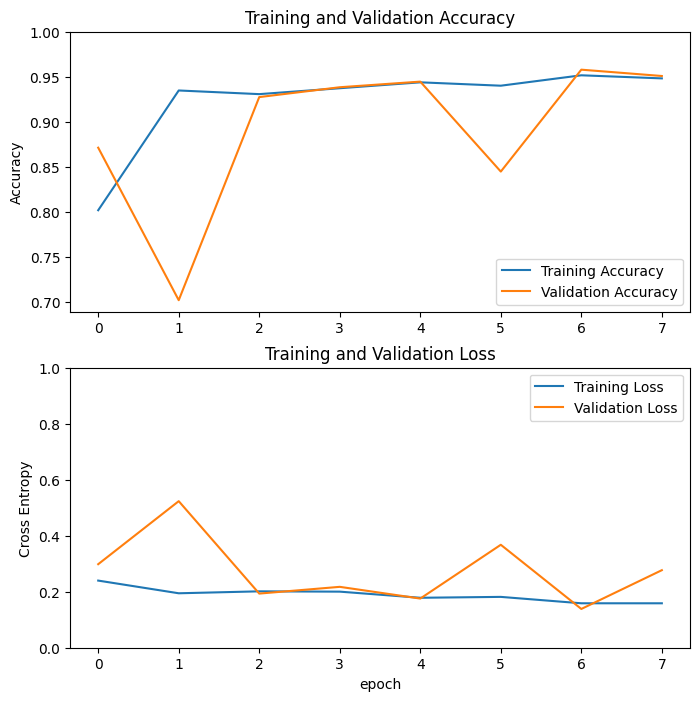

In [42]:
# without learning rate schedule -- l1 = 0.01
loss_accuracy_plot(history)

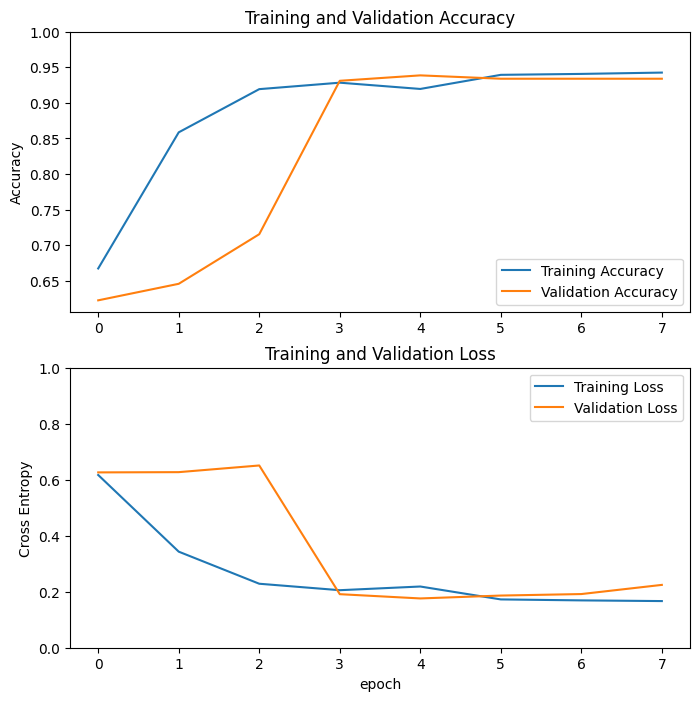

In [58]:
# when lr = 0.01 and cos_schedule
loss_accuracy_plot(history)

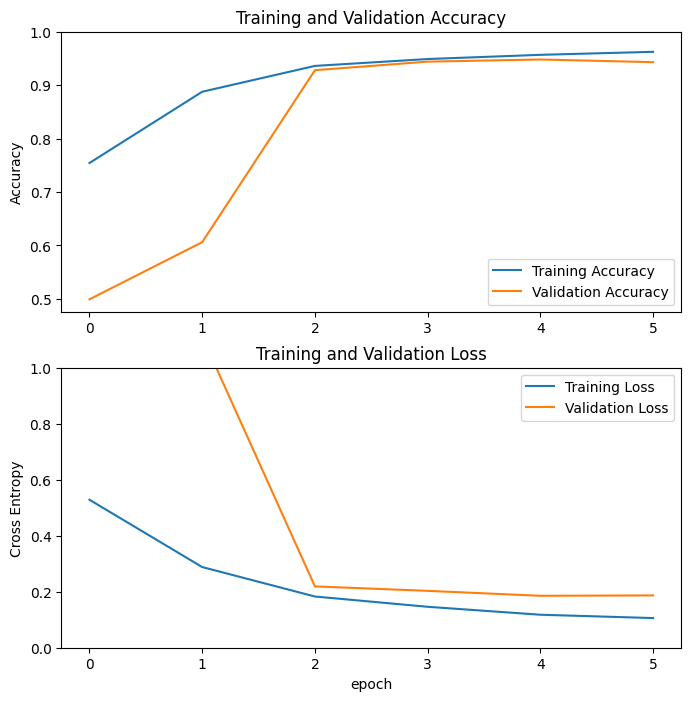

In [69]:
# when lr = 0.01 and cos_schedule
loss_accuracy_plot(history)

#### Evaluation

In [ ]:
# using exp_schedule
model.evaluate(test_data)

32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.9380 - auc: 0.9809 - fn: 39.0000 - fp: 23.0000 - loss: 0.2161 - precision: 0.9514 - recall: 0.9202 - tn: 488.0000 - tp: 450.0000


[0.21613171696662903,
 0.9380000233650208,
 450.0,
 23.0,
 488.0,
 39.0,
 0.9513742327690125,
 0.9202454090118408,
 0.9809086918830872]

In [59]:
# using cos_schedule
model.evaluate(test_data)

87/87 ━━━━━━━━━━━━━━━━━━━━ 36s 197ms/step - accuracy: 0.9303 - auc: 0.9734 - fn: 38.0000 - fp: 154.0000 - loss: 0.2018 - precision: 0.8956 - recall: 0.9720 - tn: 1243.0000 - tp: 1321.0000


[0.20183350145816803,
 0.9303337931632996,
 1321.0,
 154.0,
 1243.0,
 38.0,
 0.8955932259559631,
 0.9720382690429688,
 0.973422110080719]

In [40]:
model.save('model1.keras')

In [118]:
labels = []
predictions = []
for images, batch_label in test_data:
    labels.extend(batch_label.numpy())
    pred = model.predict_on_batch(images)[:, 0]
    predictions.extend(pred)

labels = np.array(labels, dtype=int)
predictions = np.array(predictions)
labels.shape, predictions.shape

((2756,), (2756,))

[[1299   92]
 [  56 1309]]


Text(0.5, 36.72222222222221, 'Predicted')

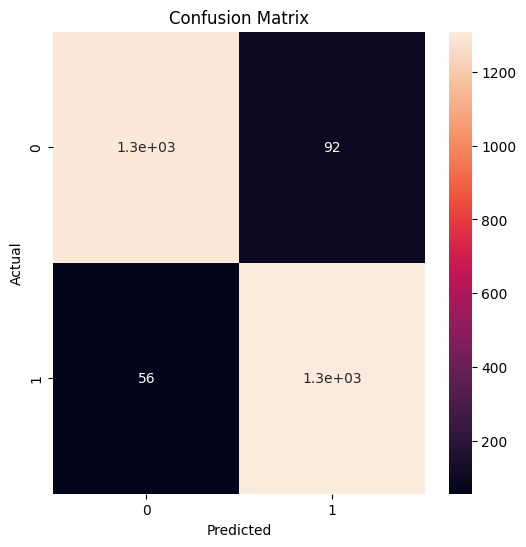

In [155]:
threshold = 0.64
cm = confusion_matrix(labels, predictions > threshold)
print(cm)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
#[[1287  104]
# [  41 1324]]

In [135]:

classification_report(labels, predictions > threshold, output_dict=True)

{'0': {'precision': 0.9691265060240963,
  'recall': 0.9252336448598131,
  'f1-score': 0.9466715704303053,
  'support': 1391.0},
 '1': {'precision': 0.927170868347339,
  'recall': 0.96996336996337,
  'f1-score': 0.9480844969566774,
  'support': 1365.0},
 'accuracy': 0.9473875181422351,
 'macro avg': {'precision': 0.9481486871857177,
  'recall': 0.9475985074115916,
  'f1-score': 0.9473780336934914,
  'support': 2756.0},
 'weighted avg': {'precision': 0.948346591137023,
  'recall': 0.9473875181422351,
  'f1-score': 0.9473713689457255,
  'support': 2756.0}}

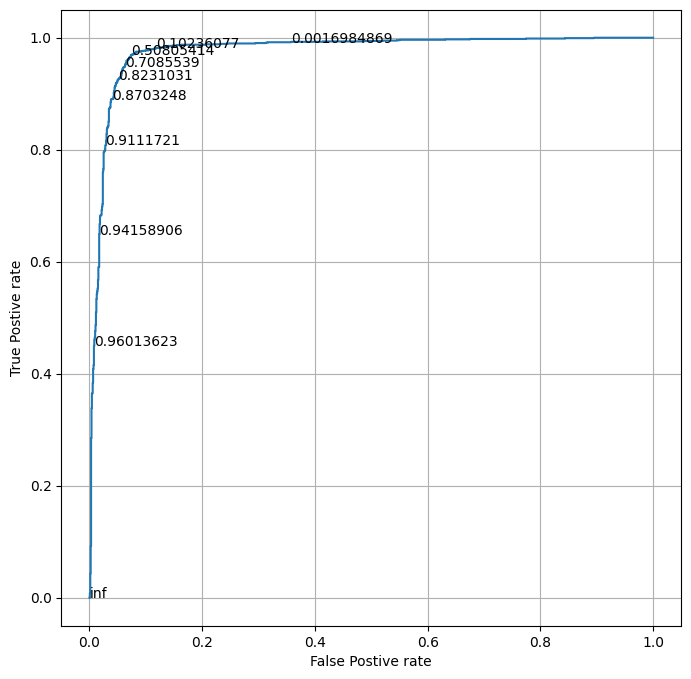

In [147]:
fp, tp, thresholds = roc_curve(labels, predictions)
plt.figure(figsize=(8, 8))
plt.plot(fp, tp)
plt.xlabel("False Postive rate")
plt.ylabel("True Postive rate")

plt.grid()
for i in range(0,  len(thresholds), 25):
  plt.text(fp[i], tp[i], threshold[i])
plt.show()
